In [ ]:
%pip install gym
%pip install numpy
%pip install torch
%pip install optuna
%pip install plotly
%pip install nbformat

def reload_module(m):
    import importlib
    importlib.reload(m)

import numpy as np
import torch
import random
from collections import deque
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim
import uts
from consts import *
import optuna
import optuna.visualization as vis
import consts
from te import TradingEnv

# avoid caching
reload_module(uts) 
reload_module(consts) 

utils = uts.Utilities(is_test=consts.IS_TEST, test_num=consts.TEST_NUM)
etf_dfs = utils.get_dataframes('data/ETFs')
stock_dfs = utils.get_dataframes('data/Stocks') 

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


[I 2025-05-25 22:56:51,626] A new study created in memory with name: no-name-7d47f418-fd6b-4919-b847-9ba1816eed0a
/var/folders/39/b1_5gh0n1c19tnncpdphyxjm0000gn/T/ipykernel_10314/1340854273.py:44: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:257.)
  s = torch.FloatTensor(s)
[I 2025-05-25 22:57:06,198] Trial 0 finished with value: 1.5133991837501526e-10 and parameters: {'gamma': 0.8759609811279295, 'tau': 0.007178432583178212, 'lr_actor': 1.7746050773526238e-05, 'lr_critic': 0.00017963572277174367, 'batch_size': 16, 'memory_size': 9451}. Best is trial 0 with value: 1.5133991837501526e-10.
[I 2025-05-25 22:57:20,049] Trial 1 finished with value: 0.0 and parameters: {'gamma': 0.8742394792642946, 'tau': 0.009765873189617687, 'lr_actor': 0.00016923

Best trial params:
{'gamma': 0.8759609811279295, 'tau': 0.007178432583178212, 'lr_actor': 1.7746050773526238e-05, 'lr_critic': 0.00017963572277174367, 'batch_size': 16, 'memory_size': 9451}


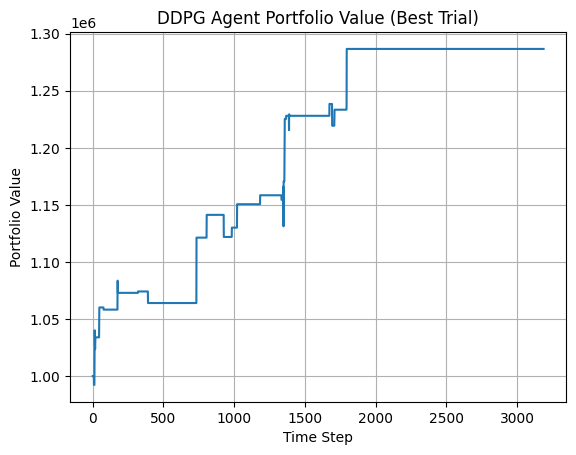

[I 2025-05-25 22:59:22,889] A new study created in memory with name: no-name-1557b49a-f1d9-4bea-ad4c-a1d90d0ba2e0
[I 2025-05-25 22:59:37,303] Trial 0 finished with value: 2.3283064365386964e-11 and parameters: {'gamma': 0.8682359351276848, 'tau': 0.00907085157982242, 'lr_actor': 0.00011040569347175406, 'lr_critic': 2.0996368171569705e-05, 'batch_size': 16, 'memory_size': 8297}. Best is trial 0 with value: 2.3283064365386964e-11.
[I 2025-05-25 22:59:53,443] Trial 1 finished with value: 0.0 and parameters: {'gamma': 0.9150342301833253, 'tau': 0.004534246130937633, 'lr_actor': 0.00013274249222048286, 'lr_critic': 1.996064633405335e-05, 'batch_size': 64, 'memory_size': 4163}. Best is trial 0 with value: 2.3283064365386964e-11.
[I 2025-05-25 23:00:09,993] Trial 2 finished with value: 0.0 and parameters: {'gamma': 0.923273280561514, 'tau': 0.004814756579398695, 'lr_actor': 1.7712818721798723e-05, 'lr_critic': 5.5504733152311284e-05, 'batch_size': 64, 'memory_size': 8159}. Best is trial 0 wit

Best trial params:
{'gamma': 0.8809496126658796, 'tau': 0.0024363499973390442, 'lr_actor': 0.0005010216094383807, 'lr_critic': 0.0004001004294397229, 'batch_size': 64, 'memory_size': 8291}


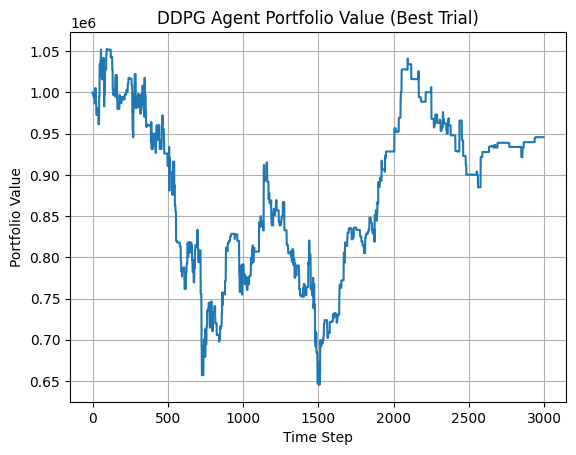

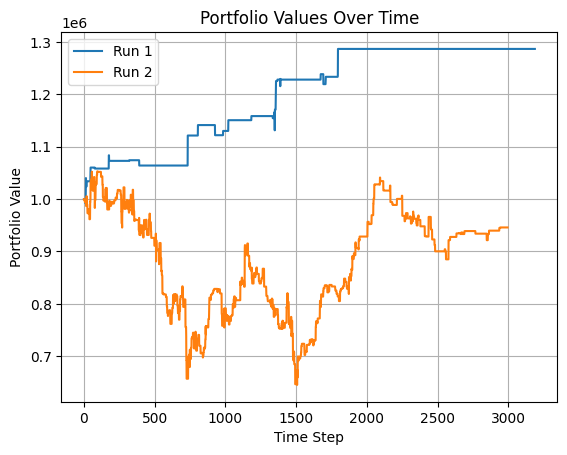

In [4]:
class DDPGAgent:
    def __init__(self, state_dim, action_dim, gamma=0.99, tau=0.005, lr_actor=1e-4, lr_critic=1e-3, batch_size=32, memory_size=10000):
        self.actor = nn.Sequential(
            nn.Linear(state_dim, 64), nn.ReLU(),
            nn.Linear(64, 64), nn.ReLU(),
            nn.Linear(64, action_dim),
            nn.Softmax(dim=-1)
        )
        self.critic = nn.Sequential(
            nn.Linear(state_dim + action_dim, 64), nn.ReLU(),
            nn.Linear(64, 64), nn.ReLU(),
            nn.Linear(64, 1)
        )
        self.target_actor = nn.Sequential(*[layer for layer in self.actor])
        self.target_critic = nn.Sequential(*[layer for layer in self.critic])
        self.target_actor.load_state_dict(self.actor.state_dict())
        self.target_critic.load_state_dict(self.critic.state_dict())

        self.actor_optimizer = optim.Adam(self.actor.parameters(), lr=lr_actor)
        self.critic_optimizer = optim.Adam(self.critic.parameters(), lr=lr_critic)

        self.gamma = gamma
        self.tau = tau
        self.replay_buffer = deque(maxlen=memory_size)
        self.batch_size = batch_size

    def select_action(self, state):
        state_tensor = torch.FloatTensor(state).unsqueeze(0)
        with torch.no_grad():
            action_probs = self.actor(state_tensor).squeeze().numpy()
        return np.random.choice(len(action_probs), p=action_probs)

    def remember(self, s, a, r, s2, done):
        a_onehot = np.zeros(3)
        a_onehot[a] = 1
        self.replay_buffer.append((s, a_onehot, r, s2, done))

    def train(self):
        if len(self.replay_buffer) < self.batch_size:
            return
        batch = random.sample(self.replay_buffer, self.batch_size)
        s, a, r, s2, d = zip(*batch)

        s = torch.FloatTensor(s)
        a = torch.FloatTensor(a)
        r = torch.FloatTensor(r).unsqueeze(1)
        s2 = torch.FloatTensor(s2)
        d = torch.FloatTensor(d).unsqueeze(1)

        with torch.no_grad():
            a2 = self.target_actor(s2)
            q_next = self.target_critic(torch.cat([s2, a2], dim=1))
            q_target = r + self.gamma * q_next * (1 - d)

        q_current = self.critic(torch.cat([s, a], dim=1))
        critic_loss = nn.MSELoss()(q_current, q_target)

        self.critic_optimizer.zero_grad()
        critic_loss.backward()
        self.critic_optimizer.step()

        action_pred = self.actor(s)
        actor_loss = -self.critic(torch.cat([s, action_pred], dim=1)).mean()

        self.actor_optimizer.zero_grad()
        actor_loss.backward()
        self.actor_optimizer.step()

        # Soft update
        for target_param, param in zip(self.target_actor.parameters(), self.actor.parameters()):
            target_param.data.copy_(self.tau * param.data + (1 - self.tau) * target_param.data)

        for target_param, param in zip(self.target_critic.parameters(), self.critic.parameters()):
            target_param.data.copy_(self.tau * param.data + (1 - self.tau) * target_param.data)

# Objective function for Optuna
def optimize_ddpg(trial, prices, env):
    gamma = trial.suggest_float('gamma', 0.85, 0.999)
    tau = trial.suggest_float('tau', 0.001, 0.01)
    lr_actor = trial.suggest_float('lr_actor', 1e-5, 1e-3, log=True)
    lr_critic = trial.suggest_float('lr_critic', 1e-5, 1e-3, log=True)
    batch_size = trial.suggest_categorical('batch_size', [16, 32, 64])
    memory_size = trial.suggest_int('memory_size', 2000, 10000)

    agent = DDPGAgent(state_dim=env.window_size,
                      action_dim=3,
                      gamma=gamma,
                      tau=tau,
                      lr_actor=lr_actor,
                      lr_critic=lr_critic,
                      batch_size=batch_size,
                      memory_size=memory_size)

    rewards = []

    for ep in range(consts.EPISODES):
        state = env.reset()
        total_reward = 0
        done = False
        while not done:
            action = agent.select_action(state)
            next_state, reward, done, _ = env.step(action)
            agent.remember(state, action, reward, next_state, done)
            agent.train()
            state = next_state
            total_reward += reward
        rewards.append(total_reward)

    return np.mean(rewards)

class DDPGObjective:
    def __init__(self, prices, env):
        self.prices = prices
        self.env = env

    def __call__(self, trial):
        return optimize_ddpg(trial, self.prices, self.env)

def plot_perf(best_params, env):
    agent = DDPGAgent(
        state_dim=env.window_size,
        action_dim=3,
        gamma=best_params['gamma'],
        tau=best_params['tau'],
        lr_actor=best_params['lr_actor'],
        lr_critic=best_params['lr_critic'],
        batch_size=best_params['batch_size'],
        memory_size=best_params['memory_size']
    )

    portfolio_values = []
    state = env.reset()
    done = False
    while not done:
        action = agent.select_action(state)
        next_state, reward, done, _ = env.step(action)
        portfolio_values.append(env.get_value())
        state = next_state

    plt.plot(portfolio_values)
    plt.title("DDPG Agent Portfolio Value (Best Trial)")
    plt.xlabel("Time Step")
    plt.ylabel("Portfolio Value")
    plt.grid(True)
    plt.show()

    return portfolio_values

def plot_ddpg_res():
    portfolio_vals_arr = []
    for df in stock_dfs[:consts.RL_LIMIT]:
        prices = df['Close'].values
        env = TradingEnv(prices)
        study = optuna.create_study(direction='maximize')
        study.optimize(DDPGObjective(prices, env), n_trials=10)

        best_params = study.best_trial.params
        print("Best trial params:")
        print(best_params)

        try:
            fig = vis.plot_optimization_history(study)
            fig.show()

            fig2 = vis.plot_param_importances(study)
            fig2.show()
        except Exception:
            # since the number of trials and episodes are relatively small, optuna sometimes returns an error
            print("Error during plotting")

        portfolio_values = plot_perf(best_params, env)
        portfolio_vals_arr.append(portfolio_values)
    
    for i, portfolio_values in enumerate(portfolio_vals_arr):
        plt.plot(portfolio_values, label=f'Run {i+1}')

    plt.title('Portfolio Values Over Time')
    plt.xlabel('Time Step')
    plt.ylabel('Portfolio Value')
    plt.legend()
    plt.grid(True)
    plt.show() 

plot_ddpg_res()